In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Always set ROOT correctly from inside /notebooks
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_PROCESSED = os.path.join(ROOT, "data", "processed")

# Load the processed dataset
df = pd.read_parquet(os.path.join(DATA_PROCESSED, "pit_within_3_laps.parquet"))

print("Loaded:", df.shape)
print(df["PitWithinNextNLaps"].value_counts())


Loaded: (2586, 15)
PitWithinNextNLaps
0    2572
1      14
Name: count, dtype: int64


In [9]:
y = df["PitWithinNextNLaps"].astype(int)
X = df.drop(columns=["PitWithinNextNLaps", "Driver", "Season", "GP"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"   # key defense-like baseline
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Balanced Baseline Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Balanced Baseline F1:", round(f1_score(y_test, y_pred, zero_division=0), 3))
print(classification_report(y_test, y_pred, zero_division=0))


Balanced Baseline Accuracy: 0.994
Balanced Baseline F1: 0.0
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       515
           1       0.00      0.00      0.00         3

    accuracy                           0.99       518
   macro avg       0.50      0.50      0.50       518
weighted avg       0.99      0.99      0.99       518



In [17]:
# Get pit-stop probabilities
proba = model.predict_proba(X_test)[:, 1]

print("Pit probability stats:")
print("min:", proba.min())
print("mean:", proba.mean())
print("max:", proba.max())

THRESHOLD = 0.05  # we may change this after seeing max()

y_pred_thresh = (proba >= THRESHOLD).astype(int)

from sklearn.metrics import f1_score, classification_report

print("Thresholded F1:",
      f1_score(y_test, y_pred_thresh, zero_division=0))

print("Predicted positives:", y_pred_thresh.sum())
print(classification_report(y_test, y_pred_thresh, zero_division=0))



Pit probability stats:
min: 0.0
mean: 0.004140926640926641
max: 0.1725
Thresholded F1: 0.1111111111111111
Predicted positives: 15
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       515
           1       0.07      0.33      0.11         3

    accuracy                           0.97       518
   macro avg       0.53      0.65      0.55       518
weighted avg       0.99      0.97      0.98       518



In [11]:
def adversarial_noise_attack(X, epsilon=0.02, seed=42):
    """
    Multiply numeric features by (1 + noise), where noise is uniform in [-epsilon, +epsilon].
    epsilon=0.02 means up to ±2% tampering.
    """
    rng = np.random.default_rng(seed)
    noise = rng.uniform(-epsilon, epsilon, size=X.shape)
    return X * (1 + noise)


In [18]:
X_test_adv = adversarial_noise_attack(X_test, epsilon=0.02, seed=42)

y_pred_adv = model.predict(X_test_adv)
proba_adv = model.predict_proba(X_test_adv)[:, 1]

print("Adversarial Accuracy:", round(accuracy_score(y_test, y_pred_adv), 3))
print("Adversarial F1:", round(f1_score(y_test, y_pred_adv, zero_division=0), 3))

print("\nAdversarial pit-probability stats:")
print("min:", proba_adv.min(), "mean:", proba_adv.mean(), "max:", proba_adv.max())


Adversarial Accuracy: 0.994
Adversarial F1: 0.0

Adversarial pit-probability stats:
min: 0.0 mean: 0.0037451737451737453 max: 0.0975


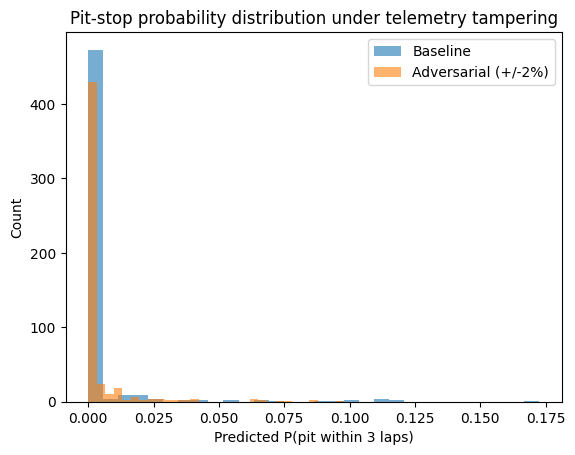

In [19]:
plt.hist(proba, bins=30, alpha=0.6, label="Baseline")
plt.hist(proba_adv, bins=30, alpha=0.6, label="Adversarial (+/-2%)")
plt.legend()
plt.title("Pit-stop probability distribution under telemetry tampering")
plt.xlabel("Predicted P(pit within 3 laps)")
plt.ylabel("Count")
plt.show()
